# Run optimiser for different Cherry Tables

## Imports

In [181]:
import pickle
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
import functions as func
from scipy.optimize import minimize, Bounds
from scipy.stats import norm, order_statistic
from tqdm import tqdm
import pandas as pd
from importlib import reload
from statistics import NormalDist
import matplotlib.pyplot as plt
from hashlib import sha256
import mmh3
import matplotlib.patches as mpatches
reload(func)

<module 'functions' from 'c:\\Users\\psymf9\\PhD Repositories\\cherry-picking-reduction-functions\\plots\\higher_costs\\N_16\\constructing_table\\functions.py'>

## Constants

In [182]:
N = 2 ** 16
p = 1-e**-2 # our table coverage
cost_factors = range(5, 31, 5)  # cost factors to simulate
alpha = 0.95  # maximality factor

## Numerical Optimisation

In [183]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor, lower_bound):   # add v_cost if want vanilla cost to be set beforehand
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    if alpha == 1:
        m_0 = N
    else:
        m_0 = round(mt_target/(1-alpha))    # our starting m_0

    
    ## set the bound and target function
    bound = Bounds([lower_bound for i in range(t)], [float('inf') for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = func.vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - func.cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    # 5000000 normally
    res = minimize(lambda Kj: func.m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps": 1, "ftol": 1})
    
    ## res.x is the result of the optimization
    final_cost, m_values = func.cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Smth Smth Smth

### Adjust m_t in simulation

In [184]:
# adjust the sumulated cost and m_t
def adjust_simulation(m_values, final_cost, N):
    # try and calculate the last m_t
    m = m_values[-1]
    vcost = final_cost

    # Calculate E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m
    average = N * (1 - E1)

    # check variance
    if N * ((N - 1) * E2 + E1 - N * E1 ** 2) < 0:
        # if it is negative (error), set it to 0
        variance = 0
    else:
        # count the variance otherwise
        variance = sqrt(N * ((N - 1) * E2 + E1 - N * E1 ** 2))

    # add on the number of hashes done - no reductions as we are just doing mod which is already fast
    vcost =  vcost + m + 1 / 577.44 

    # find the m_j+1
    m = average + NormalDist().inv_cdf((1 - pi / 8) / (1 - pi / 4 + 1)) * variance

    # return the adjusted values
    return m, vcost

## Run

### Run Simulation

In [185]:
%%script false

# run simulation for different alphas
reload(func)

N = 2 ** 16
t = round(log(1-p)/log(1-N**(-1/3)))
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
starpoint_sets = []
optimisation_results = []
optimisation_kis = []
optimisation_cost = []
optimisation_mt = []

for alpha in alphas:
    # run the optimisation
    kis, m_0, final_cost, m_values = optimise_kj(N, p, alpha, 5, 1)
    optimisation_kis.append(kis)
    # adjust the simulation results and store
    adjusted_m, adjusted_cost = adjust_simulation(m_values, final_cost, N)
    m_values.append(adjusted_m)
    result = [kis, m_0, final_cost, m_values]
    optimisation_results.append(result)
    optimisation_cost.append(final_cost)
    # store the simulated m_t
    optimisation_mt.append(adjusted_m)

# store optimisation_results in a pickle file
with open("simulations/cherry_N_20_different_alpha_0.5_0.95_optimisation_results.pkl", "wb") as f:
    pickle.dump(optimisation_results, f)

Couldn't find program: 'false'


### Use Simulation to Build Tables

In [186]:
%%script false

# need to regenerate the tables for each alpha and store their costs
reload(func)

samples = 1
generation_results = []
generation_mt = []
generation_costs = []

for a, alpha in enumerate(alphas):
    # build the actual table - 100 times 
    # first generate starpoints and store them
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
    this_alpha_startpoints = []
    # generate sample sets of starpoints
    for i in range(samples):
        starpoints = set()
        while len(starpoints) < (cherry_m_0):
            starpoints.add(random.randint(0, N-1))

        this_alpha_startpoints.append(starpoints)
    # append to main list
    starpoint_sets.append(this_alpha_startpoints)

    ##############################################################

    # build the cherry table sample times and store it for later
    this_alpha_tables = []
    this_alpha_mt = []
    this_alpha_costs = []

    # get the optimisation kis for this alpha
    optimisation_kis_for_alpha = optimisation_kis[a]

    # build sample tables
    for i in range(samples):
        # get starpoints
        starpoints = this_alpha_startpoints[i]
        # make the table with these startpoints
        table, rf_indexes, hashes, reductions, duration = func.build_cherry_table(N, t, starpoints, optimisation_kis_for_alpha)
        # append to this alpha's tables
        this_alpha_tables.append((table, rf_indexes))
        this_alpha_mt.append(len(table))
        this_alpha_costs.append(hashes + (reductions * 1/577.44))  # total cost is hashes + reductions * 1/577.44
    
    # append to main list
    generation_results.append(this_alpha_tables)
    generation_mt.append(this_alpha_mt)
    generation_costs.append(this_alpha_costs)

###################################################################

# store in a csv file
with open("cherry_N_216_different_alpha_0.5_0.95_with_cost_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    cost_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
        cost_headers.append(f"cost_{i+1}")
    
    f_alpha.writerow(["alpha", "optimiser_mt"] + trial_headers  + ["optimiser_cost"] + cost_headers)

    # add in data for each alpha
    for i in range(len(alphas)):
        row = [alphas[i], optimisation_mt[i]] + generation_mt[i] + [optimisation_cost[i]] + generation_costs[i]
        f_alpha.writerow(row)

Couldn't find program: 'false'


In [187]:
%%script false

# store in a pickle file
with open("simulations/cherry_N_16_alpha_0.5_kis.pkl", "wb") as f:
    pickle.dump(optimisation_kis[0], f)


Couldn't find program: 'false'


### Load data 

In [188]:

# need to get optimisation_mt and generation mt
optimisation_mt = []

with open("simulations/cherry_N_20_different_alpha_0.5_0.95_optimisation_results.pkl", "rb") as f:
    results = pickle.load(f)
    for result in results:
        optimisation_mt.append(result[3][-1])  # get the last m_t


### Get Expected vanilla Table values 


In [189]:
alphas = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

# calculate expected m_t
expected_mts = []
# mt-max = 2N/t+2
# mt = alpha * mt-max
t = round(log(1-p)/log(1-N**(-1/3)))
mt_max = (2*N)/(t + 2)
for alpha in alphas:
    expected_mts.append(round(alpha * mt_max))

In [190]:
# given the simulation result for alpha = 0.5, plot what we should expect as we increase alpha
expected_simulation_mts = []
base = optimisation_mt[0]  # get the base mt for alpha = 0.5
for a, alpha in enumerate(alphas):
    expected_simulation_mts.append(round(base * (alpha / alphas[0])))

# same for taking the actual mt from actual tables
expected_actual_mts = []
data_cherry = pd.read_csv("cherry_N_216_different_alpha_0.5_0.95_with_cost_results.csv")
base_actual = data_cherry["trial_1"][0]  # get the base actual mt for alpha = 0.5
for a, alpha in enumerate(alphas):
    expected_actual_mts.append(round(base_actual * (alpha / alphas[0])))


### Plot

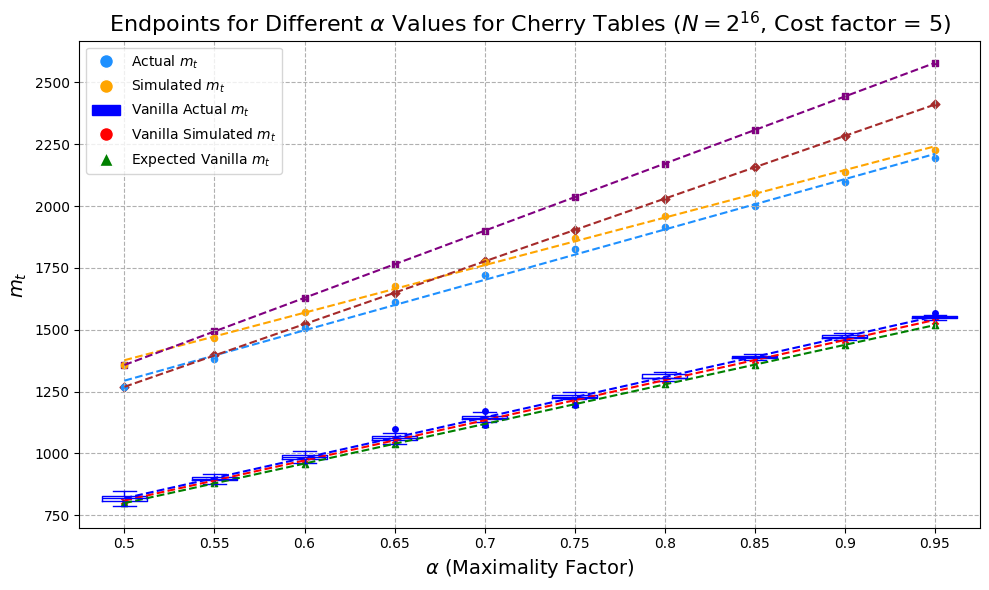

In [191]:
# plot scatter plot of optimisation mt vs generated mt
x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))

# plot simulated cost as scatter
# plt.scatter(x_indicies, optimisation_mt, color='orange', label='Simulated $m_t$ ', s=20)
# plt.scatter(x_indicies, [mt[0] for mt in generation_mt], color='dodgerblue', label='Actual $m_t$', s=20)

# plot what we expect for cherry tables given 0.5 alpha simulation
plt.scatter(x_indicies, expected_simulation_mts, color='purple', label='Expected Cherry $m_t$ based on simulation at 0.5', s=20, marker='s')
# plot what we expect for cherry tables given 0.5 alpha actual
plt.scatter(x_indicies, expected_actual_mts, color='brown', label='Expected Cherry $m_t$ based on actual at 0.5', s=20, marker='D')

# # read in from file for cherry tables
plt.scatter(x_indicies, data_cherry['optimiser_mt'], color='orange', label='Cherry Simulated $m_t$', s=20)
plt.scatter(x_indicies, data_cherry['trial_1'], color='dodgerblue', label='Cherry Actual $m_t$', s=20)



# plot simulated and actual for vanilla tables as well
data_vanilla = pd.read_csv("vanilla_N_16_different_alpha_0.5_0.95_with_cost_results.csv")
x_indicies = range(len(alphas))
plt.scatter(x_indicies, data_vanilla['optimiser_mt'], color='red', label='Vanilla Simulated $m_t$', s=20, marker='x')
# for actual vanilla - convert samples from dataframe to a single list for boxplot
plt.boxplot([data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='blue'),
            medianprops=dict(color='blue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markerfacecolor='blue', marker='o', markersize=5, markeredgecolor='none'))
# plot expected vanilla mt in green
plt.scatter(x_indicies, expected_mts, color='green', label='Expected Vanilla $m_t$', s=20, marker='^')

# plot lines of best fit
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, optimisation_mt, 1))(x_indicies), color='orange', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, data_cherry['trial_1'], 1))(x_indicies), color='dodgerblue', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, expected_simulation_mts, 1))(x_indicies), color='purple', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, expected_actual_mts, 1))(x_indicies), color='brown', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, data_vanilla['optimiser_mt'], 1))(x_indicies), color='red', linestyle='--')
# plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, [mt[0] for mt in data.iloc[:,2:22].values], 1))(x_indicies), color='blue', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, [np.mean(data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten()) for alpha in alphas], 1))(x_indicies), color='blue', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, expected_mts, 1))(x_indicies), color='green', linestyle='--')

# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values for Cherry Tables ($N=2^{16}$, Cost factor = 5)', fontsize=16)

# manually add legend
box_legend = mpatches.Patch(color="blue", label="Vanilla Actual $m_t$")
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Actual $m_t$', markerfacecolor='dodgerblue', markersize=10), plt.Line2D([0], [0], marker='o', color='w', label='Simulated $m_t$', markerfacecolor='orange', markersize=10), box_legend, plt.Line2D([0], [0], marker='o', color='w', label='Vanilla Simulated $m_t$', markerfacecolor='red', markersize=10), plt.Line2D([0], [0], marker='^', color='w', label='Expected Vanilla $m_t$', markerfacecolor='green', markersize=10)])   

plt.tight_layout()  
plt.show()

### Running multiple trials for the tables 

#### get the actual tables

In [192]:
%%script false

# get kis & optimisation costs
kis = []
optimisation_cost = []
for result in results:
    kis.append(result[0])
    optimisation_cost.append(result[2])

##############################################################
samples = 10
generation_results = []
generation_mt = []
generation_costs = []
startpoint_sets = []

for a, alpha in enumerate(alphas):
    # build the actual table - 100 times 
    # first generate starpoints and store them
    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
    this_alpha_startpoints = []
    # generate sample sets of starpoints
    for i in range(samples):
        starpoints = set()
        while len(starpoints) < (cherry_m_0):
            starpoints.add(random.randint(0, N-1))

        this_alpha_startpoints.append(starpoints)
    # append to main list
    startpoint_sets.append(this_alpha_startpoints)

    ##############################################################

    # build the cherry table sample times and store it for later
    this_alpha_tables = []
    this_alpha_mt = []
    this_alpha_costs = []

    # get the optimisation kis for this alpha
    optimisation_kis_for_alpha = kis[a]

    # build sample tables
    for i in range(samples):
        # get starpoints
        starpoints = this_alpha_startpoints[i]
        # make the table with these startpoints
        table, rf_indexes, hashes, reductions, duration = func.build_cherry_table(N, t, starpoints, optimisation_kis_for_alpha)
        # append to this alpha's tables
        this_alpha_tables.append((table, rf_indexes))
        this_alpha_mt.append(len(table))
        this_alpha_costs.append(hashes + (reductions * 1/577.44))  # total cost is hashes + reductions * 1/577.44
    
    # append to main list
    generation_results.append(this_alpha_tables)
    generation_mt.append(this_alpha_mt)
    generation_costs.append(this_alpha_costs)

###################################################################

# store in a csv file
with open("cherry_N_16_10_trials_different_alpha_0.5_0.95_with_cost_results.csv", "w", newline='') as f:
    f_alpha = csv.writer(f) # create a csv writer

    # create a list of headers for the different trials
    trial_headers = []
    cost_headers = []
    for i in range(samples):
        trial_headers.append(f"trial_{i+1}")
        cost_headers.append(f"cost_{i+1}")
    
    f_alpha.writerow(["alpha", "optimiser_mt"] + trial_headers  + ["optimiser_cost"] + cost_headers)

    # add in data for each alpha
    for i in range(len(alphas)):
        row = [alphas[i], optimisation_mt[i]] + generation_mt[i] + [optimisation_cost[i]] + generation_costs[i]
        f_alpha.writerow(row)

Couldn't find program: 'false'


#### Plot

In [193]:
# given the simulation result for alpha = 0.5, plot what we should expect as we increase alpha
expected_simulation_mts = []
base = optimisation_mt[9]  # get the base mt for alpha = 0.5
for a, alpha in enumerate(alphas):
    expected_simulation_mts.append(round(base * (alpha / alphas[9])))

# same for taking the actual mt from actual tables
expected_actual_mts = []
data_cherry = pd.read_csv("cherry_N_16_10_trials_different_alpha_0.5_0.95_with_cost_results.csv")
base_actual = data_cherry.loc[data_cherry['alpha'] == 0.95, data_cherry.columns[2:12]].mean(axis=1).values[0]  # mean of all the trials for alpha = 0.5
for a, alpha in enumerate(alphas):
    expected_actual_mts.append(round(base_actual * (alpha / alphas[9])))


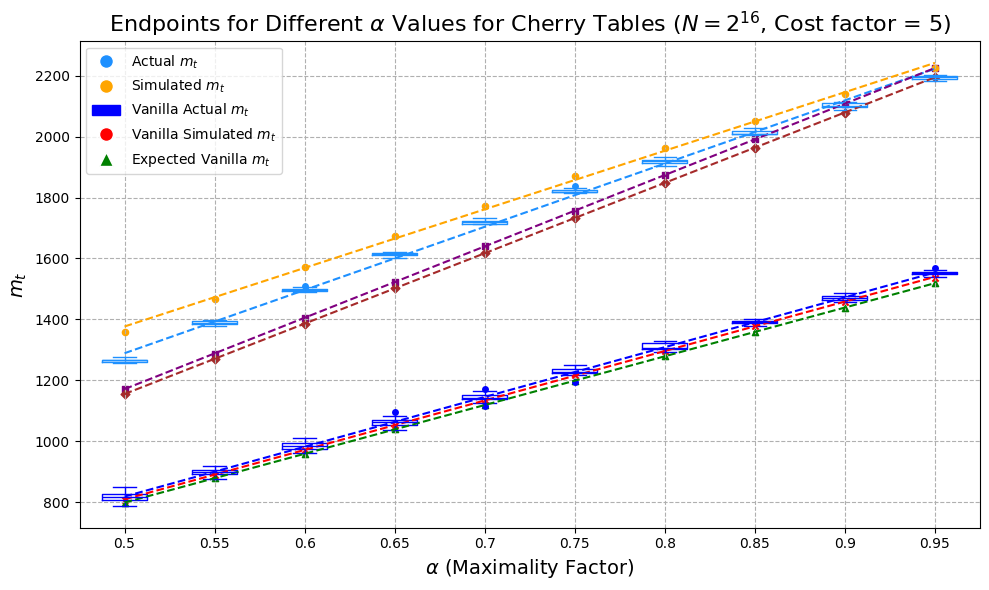

In [194]:
# plot scatter plot of optimisation mt vs generated mt
x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))

# plot simulated cost as scatter
# plt.scatter(x_indicies, optimisation_mt, color='orange', label='Simulated $m_t$ ', s=20)
# plt.scatter(x_indicies, [mt[0] for mt in generation_mt], color='dodgerblue', label='Actual $m_t$', s=20)

# plot what we expect for cherry tables given 0.5 alpha simulation
plt.scatter(x_indicies, expected_simulation_mts, color='purple', label='Expected Cherry $m_t$ based on simulation at 0.5', s=20, marker='s')
# plot what we expect for cherry tables given 0.5 alpha actual
plt.scatter(x_indicies, expected_actual_mts, color='brown', label='Expected Cherry $m_t$ based on actual at 0.5', s=20, marker='D')

# # read in from file for cherry tables
plt.scatter(x_indicies, data_cherry['optimiser_mt'], color='orange', label='Cherry Simulated $m_t$', s=20)
# plot box plot for actual cherry mt from 10 trials
plt.boxplot([data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='dodgerblue'),      
            medianprops=dict(color='dodgerblue'),
            whiskerprops=dict(color='dodgerblue'),
            capprops=dict(color='dodgerblue'),
            flierprops=dict(markerfacecolor='dodgerblue', marker='o', markersize=5, markeredgecolor='none'))



# plot simulated and actual for vanilla tables as well
data_vanilla = pd.read_csv("vanilla_N_16_different_alpha_0.5_0.95_with_cost_results.csv")
x_indicies = range(len(alphas))
plt.scatter(x_indicies, data_vanilla['optimiser_mt'], color='red', label='Vanilla Simulated $m_t$', s=20, marker='x')
# for actual vanilla - convert samples from dataframe to a single list for boxplot
plt.boxplot([data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='blue'),
            medianprops=dict(color='blue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markerfacecolor='blue', marker='o', markersize=5, markeredgecolor='none'))
# plot expected vanilla mt in green
plt.scatter(x_indicies, expected_mts, color='green', label='Expected Vanilla $m_t$', s=20, marker='^')

# plot lines of best fit
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, optimisation_mt, 1))(x_indicies), color='orange', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, data_cherry['trial_1'], 1))(x_indicies), color='dodgerblue', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, expected_simulation_mts, 1))(x_indicies), color='purple', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, expected_actual_mts, 1))(x_indicies), color='brown', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, data_vanilla['optimiser_mt'], 1))(x_indicies), color='red', linestyle='--')
# plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, [mt[0] for mt in data.iloc[:,2:22].values], 1))(x_indicies), color='blue', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, [np.mean(data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten()) for alpha in alphas], 1))(x_indicies), color='blue', linestyle='--')
plt.plot(x_indicies, np.poly1d(np.polyfit(x_indicies, expected_mts, 1))(x_indicies), color='green', linestyle='--')

# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values for Cherry Tables ($N=2^{16}$, Cost factor = 5)', fontsize=16)

# manually add legend
box_legend = mpatches.Patch(color="blue", label="Vanilla Actual $m_t$")
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Actual $m_t$', markerfacecolor='dodgerblue', markersize=10), plt.Line2D([0], [0], marker='o', color='w', label='Simulated $m_t$', markerfacecolor='orange', markersize=10), box_legend, plt.Line2D([0], [0], marker='o', color='w', label='Vanilla Simulated $m_t$', markerfacecolor='red', markersize=10), plt.Line2D([0], [0], marker='^', color='w', label='Expected Vanilla $m_t$', markerfacecolor='green', markersize=10)])   

plt.tight_layout()  
plt.show()

### Looking at m-values

In [195]:
%%script false

# maybe plot m values for alpha = 0.5 for simulated vs actual?
# need to get the m values for alpha = 0.5 when building the table 
def H(x):
    return sha256(x.to_bytes(8, 'little')).digest()  # return bytes directly

def r(y, i, ell=0):
    return mmh3.hash(y, i + ell*t, signed=False) % N

def get_m_values(N, t, startpoints, Kis):
    m_values = []
    # store table in dictionary
    # initialise the table with sp:sp pairs
    table = {sp: sp for sp in startpoints}  # store all the points then remove duplicate entries - can't do duplicate keys in dictionary anyway so we can just store all ep:sp
    m_values.append(len(table))
    # Instead of making the table chain by chain, we have to make it column by column to test what reduction function to choose
    # store reduction function indexes
    rf_indexes = []

    # for each column
    for i in tqdm(range(t), desc=f"Calculating columns: "):

        # variable to store best cherry-pick
        best_trial = -1

        # hash all current points then store with startpoints - this stores all our current points
        hashed_points = {H(mi): sp for mi, sp in table.items()}

        # we are going to continuously replace table with the best rf trial, so we empty it for now
            # we haven't lost the current points as we have them hashed in the hashed_points dictionary
        table = {}

        # get # cherry-picks for this column
        k_i = round(Kis[i])

        # trial all the reduction functions for this column
        # for rf_trial in tqdm(range(k_i), desc=f"Choosing best RF: "):
        for rf_trial in range(k_i):

            # create a trial column to store results of current trial
            trial_column = {}

            # go through each key in hashed_points and store its reduction with sp
            for x in hashed_points:
                # reduce the hash and store in column
                trial_column[r(x, rf_trial)] = hashed_points[x]

            # if trial_column is bigger than current table stored, we replace it
            if len(trial_column) > len(table):
                # replace it 
                table = trial_column
                # replace best cherry-pick
                best_trial = rf_trial

        # now store the best rf cherry pick
        rf_indexes.append(best_trial)
        # store the m value
        m_values.append(len(table))


    # finished, so return table and rf indexes
    return m_values


def get_vanilla_m_values(t, alpha, startpoints):
    m_values = []

    # list of sets to store unique values in each column
    m_i_sets = [set() for _ in range(t)]
    print(len(m_i_sets))

    # keep track of what column we're in
    column = 0

    # for each startpoint
    for sp in tqdm(startpoints):
        current_point = sp  # keep track of current point in chain -  we want to store startpoint later
        m_i_sets[column].add(current_point)  # add startpoint to first column set

        # create the chain
        for i in range(t):
            # hash then reduce the value
            current_point = r(H(current_point), i)
            m_i_sets[i].add(current_point)  # add current point to the corresponding column set
            # move to next column
            column += 1

        # finished the chain - reset column counter
        column = 0

    # now calculate mi values from the sets
    for i in range(t):
        m_values.append(len(m_i_sets[i]))


    return m_values


Couldn't find program: 'false'


In [196]:
%%script false

# get simulated m values for alpha = 0.5
# create a set of starpoints
alpha = 0.5
mt_max = (2*N)/(t+2)
mt_target = alpha * mt_max
cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0
cherry_startpoints = set()
while len(cherry_startpoints) < (cherry_m_0):
    cherry_startpoints.add(random.randint(0, N-1))

actual_m_values = get_m_values(N, t, cherry_startpoints, optimisation_kis[0])
# get actual m values for alpha = 0.5
simulated_m_values = optimisation_results[0][3]

# plot both sets of m values
plt.figure(figsize=(10,6))
plt.plot(range(t+1), simulated_m_values, marker='o', color='orange', label='Simulated $m_i$ ', markersize=8)
plt.plot(range(t+1), actual_m_values, marker='o', color='dodgerblue', label='Actual $m_i$', markersize=8)
plt.legend()
plt.xlabel('column index $i$')
plt.ylabel('$m_i$')
plt.title('Comparison of Simulated and Actual $m_i$ values for $\\alpha=0.5$')
plt.grid(True)
plt.show()

Couldn't find program: 'false'


## Add cherry tables built by sampling 

### Sampling functions

In [197]:
def get_mean(N, m):
    return N - (N*(1 - 1/N)**m)

def get_std(N, m):
    # E1 and E2
    E1 = (1 - 1 / N) ** m
    E2 = (1 - 2 / N) ** m

    return sqrt(N * (((N - 1) * E2) + E1 - (N * (E1 ** 2))))

# Cherry Table Simulation - only returns number of endpoints
def cherry_table_simulation(N, t, K, startpoints_len):

    m = startpoints_len

    # for each column
    for i in range(len(K)):
        # get the mean (loc)
        # get the standard deviation (scale)
        mean = get_mean(N, m)
        std = get_std(N, m)
        # get distribution of the current column
        column_dist = norm(loc=mean, scale=std)
        # for the next column, we want to sample K times and use the maximum
        samples = column_dist.rvs(size=round(K[i]))
        # set m to be the maximum of these samples
        m = max(samples)


    return m

### Get samples

In [ ]:
cherry_sample_simulated_mts = []

# get kis for each alpha
with open("simulations/cherry_N_20_different_alpha_0.5_0.95_optimisation_results.pkl", "rb") as f:
    optimisation_results = pickle.load(f)

K = [optimisation_results[i][0] for i in range(len(alphas))]

for alpha in alphas:

    mts = []

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    cherry_m_0 = round(mt_target/(1-alpha))    # our starting m_0

    # get the kis for this alpha
    kis_for_alpha = K[alphas.index(alpha)]

    # run 100 simulations
    for _ in range(100):
        mt = cherry_table_simulation(N, t, kis_for_alpha, cherry_m_0)
        mts.append(mt)

    cherry_sample_simulated_mts.append(mts)
    


In [205]:
# do sampling for vanilla tables as well
vanilla_sample_simulated_mts = []
K = [1 for i in range(t)]  # all kis are 1 for vanilla tables

for alpha in alphas:

    mts = []

    mt_max = (2*N)/(t+2)
    mt_target = alpha * mt_max
    vanilla_m_0 = round(mt_target/(1-alpha))    # our starting m_0

    # run 100 simulations
    for _ in range(100):
        mt = cherry_table_simulation(N, t, K, vanilla_m_0)
        mts.append(mt)

    vanilla_sample_simulated_mts.append(mts)

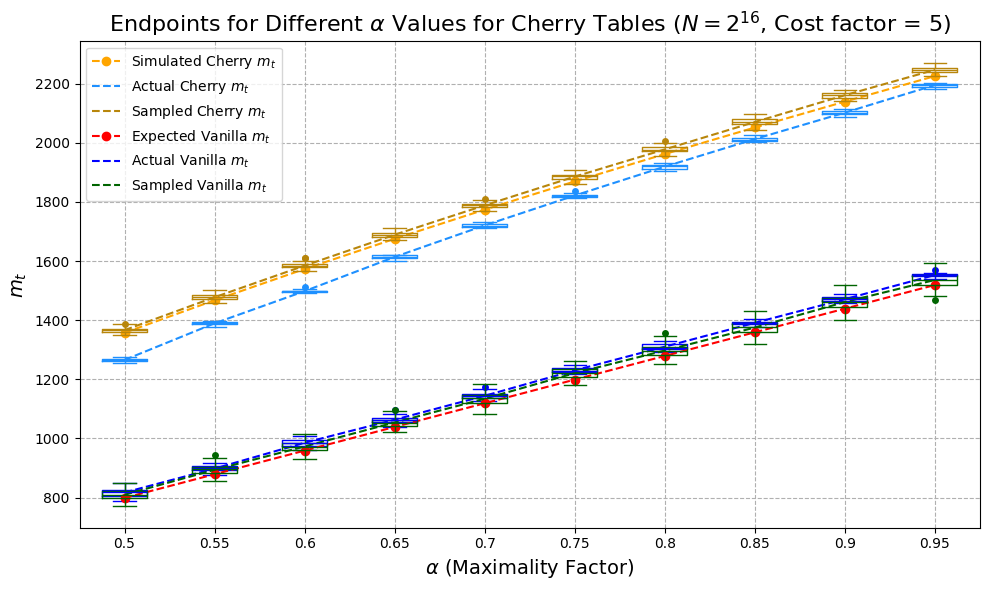

In [209]:
# plot scatter plot of optimisation mt vs generated mt
x_indicies = range(len(alphas))
plt.figure(figsize=(10,6))


# # read in from file for cherry tables
data_cherry = pd.read_csv("cherry_N_16_10_trials_different_alpha_0.5_0.95_with_cost_results.csv")
plt.plot(x_indicies, data_cherry['optimiser_mt'], color='orange', label='Simulated Cherry $m_t$', linestyle='--', marker='o')
# plot box plot for actual cherry mt from 10 trials
plt.boxplot([data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='dodgerblue'),      
            medianprops=dict(color='dodgerblue'),
            whiskerprops=dict(color='dodgerblue'),
            capprops=dict(color='dodgerblue'),
            flierprops=dict(markerfacecolor='dodgerblue', marker='o', markersize=5, markeredgecolor='none'))
# plot means of cherry boxplots
plt.plot(x_indicies, [data_cherry.loc[data_cherry['alpha'] == alpha, data_cherry.columns[2:12]].values.flatten().mean() for alpha in alphas], 
         color='dodgerblue', linestyle='--', label='Actual Cherry $m_t$')


# plot the cherry sampling method too as a boxplot
plt.boxplot(cherry_sample_simulated_mts, 
            positions=[i for i in x_indicies], widths=0.5,
            boxprops=dict(color='darkgoldenrod'),  
            medianprops=dict(color='darkgoldenrod'),
            whiskerprops=dict(color='darkgoldenrod'),
            capprops=dict(color='darkgoldenrod'),
            flierprops=dict(markerfacecolor='darkgoldenrod', marker='o', markersize=5, markeredgecolor='none'))
# plot means of cherry sampling boxplots
plt.plot([i for i in x_indicies], [np.mean(cherry_sample_simulated_mts[a]) for a in range(len(alphas))], 
         color='darkgoldenrod', linestyle='--', label='Sampled Cherry $m_t$')



# plot actual for vanilla tables as well
data_vanilla = pd.read_csv("vanilla_N_16_different_alpha_0.5_0.95_with_cost_results.csv")
x_indicies = range(len(alphas))
# for actual vanilla - convert samples from dataframe to a single list for boxplot
plt.boxplot([data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten() for alpha in alphas], 
            positions=x_indicies, widths=0.5,
            boxprops=dict(color='blue'),
            medianprops=dict(color='blue'),
            whiskerprops=dict(color='blue'),
            capprops=dict(color='blue'),
            flierprops=dict(markerfacecolor='blue', marker='o', markersize=5, markeredgecolor='none'))
# plot expected vanilla mt in green
plt.plot(x_indicies, expected_mts, color='red', label='Expected Vanilla $m_t$', marker='o', linestyle='--')
# plot means of vanilla boxplots
plt.plot(x_indicies, [data_vanilla.loc[data_vanilla['alpha'] == alpha, data_vanilla.columns[2:22]].values.flatten().mean() for alpha in alphas], 
         color='blue', linestyle='--', label='Actual Vanilla $m_t$')

# plot the vanilla sampling method too as a boxplot
plt.boxplot(vanilla_sample_simulated_mts, 
            positions=[i for i in x_indicies], widths=0.5,
            boxprops=dict(color='darkgreen'),  
            medianprops=dict(color='darkgreen'),
            whiskerprops=dict(color='darkgreen'),
            capprops=dict(color='darkgreen'),
            flierprops=dict(markerfacecolor='darkgreen', marker='o', markersize=5, markeredgecolor='none'))
# plot means of vanilla sampling boxplots
plt.plot([i for i in x_indicies], [np.mean(vanilla_sample_simulated_mts[a]) for a in range(len(alphas))], 
         color='darkgreen', linestyle='--', label='Sampled Vanilla $m_t$')



# titles and labels
plt.xlabel('$\\alpha$ (Maximality Factor)', fontsize=14)
plt.ylabel('$m_t$', fontsize=14)
plt.xticks(x_indicies, alphas)
plt.grid(linestyle="--")
plt.title('Endpoints for Different $\\alpha$ Values for Cherry Tables ($N=2^{16}$, Cost factor = 5)', fontsize=16)

# manually add legend
box_legend = mpatches.Patch(color="blue", label="Vanilla Actual $m_t$")
# plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label='Actual $m_t$', markerfacecolor='dodgerblue', markersize=10), plt.Line2D([0], [0], marker='o', color='w', label='Simulated $m_t$', markerfacecolor='orange', markersize=10), box_legend, plt.Line2D([0], [0], marker='o', color='w', label='Expected Vanilla $m_t$', markerfacecolor='green', markersize=10)])
plt.legend()
plt.tight_layout()  
plt.show()